# M3 Exploration Schedule Experiments for Atari Freeway

**Environment:** ALE/Freeway-v5
**Framework:** Stable Baselines3 + Gymnasium
**Hyperparameter Axis:** Exploration schedule (epsilon-greedy decay).

This notebook runs ten epsilon-greedy exploration experiments for the third member's sweep. Each experiment trains for 150,000 timesteps to keep the total compute budgets manageable.

## About the Environment

Freeway is an Atari game where a chicken must cross a multi-lane highway filled with moving cars.
The agent earns +1 reward for each successful crossing. Getting hit does not end the episode; it resets the chicken's position.
The agent needs to learn timing and patience: wait for gaps in traffic rather than rushing forward.

**Key properties:**
- Action space: 3 actions (up, down, no-op)
- Observation: 84x84 grayscale frames, stacked 4 deep for motion inference
- Policy: CnnPolicy (convolutional neural network for raw pixel inputs)

### Why Exploration Schedule Matters

DQN uses an epsilon-greedy policy: with probability `epsilon` it selects a random action, otherwise it selects the action with the highest Q-value.
`epsilon` typically decays from `exploration_initial_eps` to `exploration_final_eps` over `exploration_fraction` of the training budget.

- **Too fast decay:** the agent may exploit before it has seen enough diverse states.
- **Too slow decay:** the agent wastes interactions acting randomly and delays convergence.
- **Floor too high:** persistent randomness corrupts the final policy.
- **Floor too low (zero):** the agent may freeze and never try new actions again.

Freeway specifically rewards patience. The agent must learn to wait for safe gaps, which requires enough exploration to discover the right timing but not so much that it never commits to a reliable crossing strategy.

## 1. Setup

In [1]:
import os

REPO_URL = 'https://github.com/kelvintawe12/Freeway-DQN_formative3.git'
REPO_DIR = REPO_URL.rstrip('/').split('/')[-1].removesuffix('.git')

# If running on Colab, clone the repo and install dependencies.
# If running locally, just ensure we are at the project root.
if os.getcwd() == '/content':
    if not os.path.isdir(REPO_DIR):
        !git clone $REPO_URL
    %cd /content/{REPO_DIR}
    !pip install -q -r requirements.txt
else:
    if os.getcwd().endswith('notebooks'):
        os.chdir('..')
    if not os.path.isfile('requirements.txt'):
        print('Warning: requirements.txt not found. Make sure you are in the repo root.')

## 2. Verify the Environment

In [2]:
import gymnasium as gym
import ale_py
import os

if os.getcwd().endswith('notebooks'):
    os.chdir('..')

gym.register_envs(ale_py)

env = gym.make('ALE/Freeway-v5', render_mode='rgb_array')
obs, info = env.reset()
print(f'Environment: ALE/Freeway-v5')
print(f'Observation shape: {obs.shape}')
print(f'Action space: {env.action_space}')
env.close()

from config import DQNConfig, PRESETS
print(f'\nTotal presets loaded: {len(PRESETS)}')
my_presets = [k for k in sorted(PRESETS) if k.startswith('m3_')]
print(f'My presets (m3_*): {my_presets}')
print(f'Count: {len(my_presets)} experiments')

Environment: ALE/Freeway-v5
Observation shape: (210, 160, 3)
Action space: Discrete(3)

Total presets loaded: 30
My presets (m3_*): ['m3_eps_01_fastdecay', 'm3_eps_02_baseline', 'm3_eps_03_slowdecay', 'm3_eps_04_veryslow', 'm3_eps_05_highfloor', 'm3_eps_06_lowfloor', 'm3_eps_07_zerofloor', 'm3_eps_08_lowstart', 'm3_eps_09_alwaysexplore', 'm3_eps_10_aggressive']
Count: 10 experiments


A.L.E: Arcade Learning Environment (version 0.12.0+0706845)
[Powered by Stella]


## 3. Baseline Configuration

All experiments vary exactly one parameter from this shared baseline. This keeps comparisons fair.

| Parameter | Baseline Value |
|---|---|
| `learning_rate` | 1e-4 |
| `gamma` | 0.99 |
| `batch_size` | 32 |
| `buffer_size` | 100,000 |
| `exploration_initial_eps` | 1.0 |
| `exploration_final_eps` | 0.05 |
| `exploration_fraction` | 0.10 |
| `total_timesteps` | 150,000 (sweep budget) |

## 4. Epsilon-Greedy Exploration Schedule Experiments

### What is the Exploration Schedule?

The schedule controls three values:
- `exploration_initial_eps`: the starting epsilon value.
- `exploration_final_eps`: the floor epsilon value after decay.
- `exploration_fraction`: the fraction of training over which epsilon decays from start to end.

The experiments below test both the speed of decay (experiments 1-4 and 10) and the final floor (experiments 5-7), plus the effect of a lower starting epsilon (experiment 8) and a deliberately too-high final epsilon (experiment 9).

### Experiment Plan

| # | Preset | Initial eps | Final eps | Decay fraction | Expected Behavior |
|---|---|---|---|---|---|
| 1 | m3_eps_01_fastdecay | 1.0 | 0.05 | 0.02 | Exploit early; risk suboptimal policy |
| 2 | m3_eps_02_baseline | 1.0 | 0.05 | 0.10 | Reference schedule |
| 3 | m3_eps_03_slowdecay | 1.0 | 0.05 | 0.30 | More exploration; slower convergence |
| 4 | m3_eps_04_veryslow | 1.0 | 0.05 | 0.50 | Long random exploration |
| 5 | m3_eps_05_highfloor | 1.0 | 0.20 | 0.10 | Never fully greedy; noisy final policy |
| 6 | m3_eps_06_lowfloor | 1.0 | 0.01 | 0.10 | Almost fully greedy |
| 7 | m3_eps_07_zerofloor | 1.0 | 0.00 | 0.10 | No residual exploration; risk getting stuck |
| 8 | m3_eps_08_lowstart | 0.5 | 0.05 | 0.10 | Less initial random exploration |
| 9 | m3_eps_09_alwaysexplore | 1.0 | 0.30 | 0.50 | Too much exploration; weak final |
| 10 | m3_eps_10_aggressive | 1.0 | 0.02 | 0.05 | Very fast commitment; sharp contrast |

### Experiment 1: Fast epsilon decay (fraction=0.02, final=0.05)

**Hypothesis:**
Epsilon decays from 1.0 to 0.05 over only 2% of the training budget. The agent starts exploiting very early. This risks committing to a suboptimal policy before the replay buffer has collected enough diverse traffic patterns.

**Expected Behavior:**
Early plateau but possibly lower final reward if exploration was insufficient.

Parameters: `exploration_initial_eps=1.0`, `exploration_final_eps=0.05`, `exploration_fraction=0.02`

In [3]:
import os
if not os.path.exists('models/m3_eps_01_fastdecay.zip'):
    !python3 train.py --preset m3_eps_01_fastdecay --total-timesteps 150000 --notes 'Experiment 1: Fast epsilon decay (fraction=0.02, final=0.05): M3 exploration schedule sweep'
else:
    print('Model models/m3_eps_01_fastdecay.zip already exists. Skipping training.')

Model models/m3_eps_01_fastdecay.zip already exists. Skipping training.


### Experiment 2: Baseline epsilon schedule (fraction=0.10, final=0.05)

**Hypothesis:**
Epsilon decays from 1.0 to 0.05 over the first 10% of timesteps, matching the shared baseline. This is the standard DQN exploration schedule used in the other sweeps.

**Expected Behavior:**
Reference behavior: good exploration early, then stable exploitation.

Parameters: `exploration_initial_eps=1.0`, `exploration_final_eps=0.05`, `exploration_fraction=0.1`

In [4]:
import os
if not os.path.exists('models/m3_eps_02_baseline.zip'):
    !python3 train.py --preset m3_eps_02_baseline --total-timesteps 150000 --notes 'Experiment 2: Baseline epsilon schedule (fraction=0.10, final=0.05): M3 exploration schedule sweep'
else:
    print('Model models/m3_eps_02_baseline.zip already exists. Skipping training.')

Model models/m3_eps_02_baseline.zip already exists. Skipping training.


### Experiment 3: Slow epsilon decay (fraction=0.30, final=0.05)

**Hypothesis:**
Epsilon decays from 1.0 to 0.05 over 30% of training. More time is spent exploring, so the agent collects more diverse transitions and may learn a more robust final policy.

**Expected Behavior:**
Slower early convergence but possibly better and more stable final policy.

Parameters: `exploration_initial_eps=1.0`, `exploration_final_eps=0.05`, `exploration_fraction=0.3`

In [5]:
import os
if not os.path.exists('models/m3_eps_03_slowdecay.zip'):
    !python3 train.py --preset m3_eps_03_slowdecay --total-timesteps 150000 --notes 'Experiment 3: Slow epsilon decay (fraction=0.30, final=0.05): M3 exploration schedule sweep'
else:
    print('Model models/m3_eps_03_slowdecay.zip already exists. Skipping training.')

Model models/m3_eps_03_slowdecay.zip already exists. Skipping training.


### Experiment 4: Very slow epsilon decay (fraction=0.50, final=0.05)

**Hypothesis:**
Epsilon decays from 1.0 to 0.05 over half the training budget. The agent spends a long time randomly exploring, which may delay learning but can reveal rare safe crossing paths.

**Expected Behavior:**
Delayed convergence; final policy may be robust if random exploration was valuable.

Parameters: `exploration_initial_eps=1.0`, `exploration_final_eps=0.05`, `exploration_fraction=0.5`

In [6]:
import os
if not os.path.exists('models/m3_eps_04_veryslow.zip'):
    !python3 train.py --preset m3_eps_04_veryslow --total-timesteps 150000 --notes 'Experiment 4: Very slow epsilon decay (fraction=0.50, final=0.05): M3 exploration schedule sweep'
else:
    print('Model models/m3_eps_04_veryslow.zip already exists. Skipping training.')

Model models/m3_eps_04_veryslow.zip already exists. Skipping training.


### Experiment 5: High exploration floor (fraction=0.10, final=0.20)

**Hypothesis:**
The epsilon floor is 0.20, so even at the end of training 20% of actions are random. This keeps policy evaluation noisy and may prevent the agent from fully exploiting a good strategy.

**Expected Behavior:**
Noisy final policy; stochastic reward may be okay but greedy reward may suffer.

Parameters: `exploration_initial_eps=1.0`, `exploration_final_eps=0.2`, `exploration_fraction=0.1`

In [7]:
import os
if not os.path.exists('models/m3_eps_05_highfloor.zip'):
    !python3 train.py --preset m3_eps_05_highfloor --total-timesteps 150000 --notes 'Experiment 5: High exploration floor (fraction=0.10, final=0.20): M3 exploration schedule sweep'
else:
    print('Model models/m3_eps_05_highfloor.zip already exists. Skipping training.')

Model models/m3_eps_05_highfloor.zip already exists. Skipping training.


### Experiment 6: Low exploration floor (fraction=0.10, final=0.01)

**Hypothesis:**
Epsilon decays to 0.01, meaning almost all actions are greedy late in training. This is close to full exploitation with a tiny residual exploration chance.

**Expected Behavior:**
Stable final greedy policy; may be stuck if a good action was not discovered.

Parameters: `exploration_initial_eps=1.0`, `exploration_final_eps=0.01`, `exploration_fraction=0.1`

In [8]:
import os
if not os.path.exists('models/m3_eps_06_lowfloor.zip'):
    !python3 train.py --preset m3_eps_06_lowfloor --total-timesteps 150000 --notes 'Experiment 6: Low exploration floor (fraction=0.10, final=0.01): M3 exploration schedule sweep'
else:
    print('Model models/m3_eps_06_lowfloor.zip already exists. Skipping training.')

Model models/m3_eps_06_lowfloor.zip already exists. Skipping training.


### Experiment 7: Zero exploration floor (fraction=0.10, final=0.0)

**Hypothesis:**
Epsilon decays to exactly 0.0, so there is no random exploration after the decay phase. If the agent has not discovered a good state-action pair by then, it can get permanently stuck.

**Expected Behavior:**
Failure-mode example: greedy collapse if exploration was insufficient.

Parameters: `exploration_initial_eps=1.0`, `exploration_final_eps=0.0`, `exploration_fraction=0.1`

In [9]:
import os
if not os.path.exists('models/m3_eps_07_zerofloor.zip'):
    !python3 train.py --preset m3_eps_07_zerofloor --total-timesteps 150000 --notes 'Experiment 7: Zero exploration floor (fraction=0.10, final=0.0): M3 exploration schedule sweep'
else:
    print('Model models/m3_eps_07_zerofloor.zip already exists. Skipping training.')

Model models/m3_eps_07_zerofloor.zip already exists. Skipping training.


### Experiment 8: Low initial epsilon (initial=0.5, fraction=0.10, final=0.05)

**Hypothesis:**
Instead of starting fully random (epsilon=1.0), the agent starts at epsilon=0.5. Less initial exploration may lead to faster early convergence but a narrower visited state space.

**Expected Behavior:**
Faster early progress but possibly brittle final policy due to less diverse data.

Parameters: `exploration_initial_eps=0.5`, `exploration_final_eps=0.05`, `exploration_fraction=0.1`

In [10]:
import os
if not os.path.exists('models/m3_eps_08_lowstart.zip'):
    !python3 train.py --preset m3_eps_08_lowstart --total-timesteps 150000 --notes 'Experiment 8: Low initial epsilon (initial=0.5, fraction=0.10, final=0.05): M3 exploration schedule sweep'
else:
    print('Model models/m3_eps_08_lowstart.zip already exists. Skipping training.')

Model models/m3_eps_08_lowstart.zip already exists. Skipping training.


### Experiment 9: Always explore (fraction=0.50, final=0.30)

**Hypothesis:**
A very high floor (0.30) and a long decay mean 30% of actions remain random even at the end. This is a deliberate too-much-exploration contrast case.

**Expected Behavior:**
Weak final performance; useful as evidence that too much exploration hurts.

Parameters: `exploration_initial_eps=1.0`, `exploration_final_eps=0.3`, `exploration_fraction=0.5`

In [11]:
import os
if not os.path.exists('models/m3_eps_09_alwaysexplore.zip'):
    !python3 train.py --preset m3_eps_09_alwaysexplore --total-timesteps 150000 --notes 'Experiment 9: Always explore (fraction=0.50, final=0.30): M3 exploration schedule sweep'
else:
    print('Model models/m3_eps_09_alwaysexplore.zip already exists. Skipping training.')

Model models/m3_eps_09_alwaysexplore.zip already exists. Skipping training.


### Experiment 10: Aggressive exploitation (fraction=0.05, final=0.02)

**Hypothesis:**
Epsilon decays to 0.02 over only 5% of training. The agent commits to exploitation extremely fast. This is the opposite extreme to the slow-decay runs.

**Expected Behavior:**
Very fast early convergence but high risk of suboptimal policy if exploration was too brief.

Parameters: `exploration_initial_eps=1.0`, `exploration_final_eps=0.02`, `exploration_fraction=0.05`

In [12]:
import os
if not os.path.exists('models/m3_eps_10_aggressive.zip'):
    !python3 train.py --preset m3_eps_10_aggressive --total-timesteps 150000 --notes 'Experiment 10: Aggressive exploitation (fraction=0.05, final=0.02): M3 exploration schedule sweep'
else:
    print('Model models/m3_eps_10_aggressive.zip already exists. Skipping training.')

Model models/m3_eps_10_aggressive.zip already exists. Skipping training.


## 5. Results Analysis

Load the experiment log and compare all ten M3 runs.

In [13]:
import pandas as pd
import os

df = pd.read_csv('experiments/experiment_log.csv')
my_runs = df[df['run_id'].str.startswith('m3_')].sort_values('run_id')

cols = ['run_id', 'exploration_initial_eps', 'exploration_final_eps', 'exploration_fraction',
        'mean_reward', 'final_mean_reward', 'stochastic_mean_reward', 'steps_to_threshold',
        'auc_reward', 'late_reward_std', 'wall_clock_seconds']

print('M3 exploration schedule results:')
print(my_runs[[c for c in cols if c in my_runs.columns]].to_string(index=False))

if my_runs.empty:
    print('\nNo M3 rows in experiment_log.csv yet. Run the cells above first.')

M3 exploration schedule results:
                 run_id  exploration_initial_eps  exploration_final_eps  exploration_fraction  mean_reward  final_mean_reward  stochastic_mean_reward  steps_to_threshold  auc_reward  late_reward_std  wall_clock_seconds
    m3_eps_01_fastdecay                      1.0                   0.05                  0.02         22.5               21.8                    21.3             25000.0      20.083            2.769               996.1
     m3_eps_02_baseline                      1.0                   0.05                  0.10         22.5               21.8                    21.3             25000.0      21.067            1.757              1013.0
    m3_eps_03_slowdecay                      1.0                   0.05                  0.30         22.5               20.8                    21.3             50000.0      13.800            8.446               968.9
     m3_eps_04_veryslow                      1.0                   0.05                  0.

### Reward Comparison Plots

Visualize how the exploration schedule affects the key metrics.

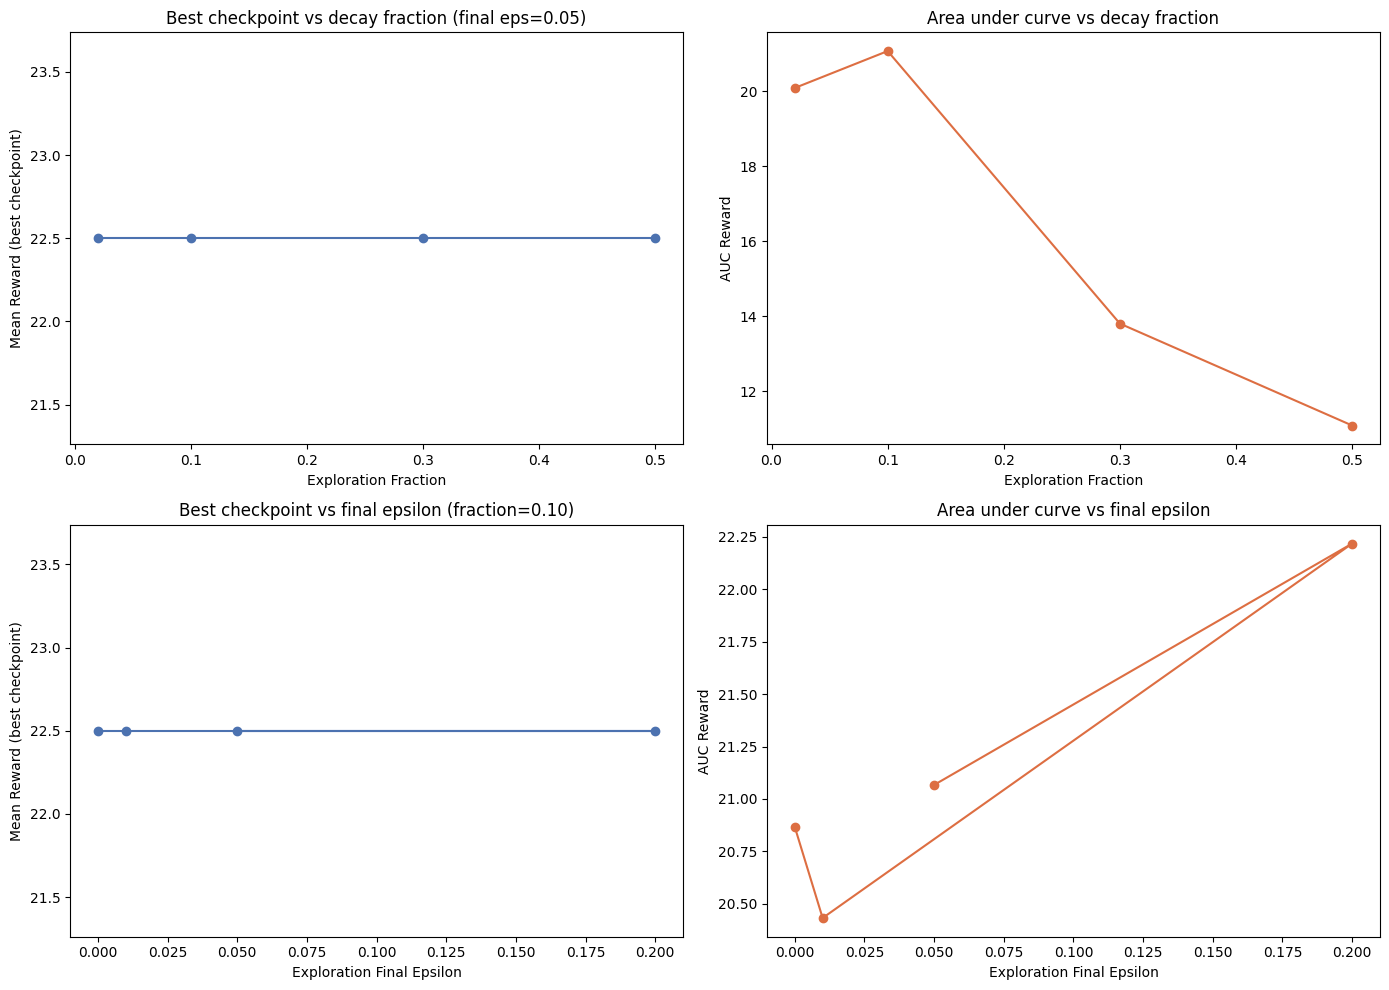

Plot saved to plots/m3_exploration_comparison.png


In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

df = pd.read_csv('experiments/experiment_log.csv')
m3_df = df[df['run_id'].str.startswith('m3_')].copy()

if m3_df.empty:
    print('No M3 rows yet. Train the presets first.')
else:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Decay fraction sweep (final_eps = 0.05 and initial_eps = 1.0)
    decay_df = m3_df[(m3_df['exploration_final_eps'] == 0.05) & (m3_df['exploration_initial_eps'] == 1.0)]
    axes[0, 0].plot(decay_df['exploration_fraction'], decay_df['mean_reward'], marker='o', color='#4C72B0')
    axes[0, 0].set_xlabel('Exploration Fraction')
    axes[0, 0].set_ylabel('Mean Reward (best checkpoint)')
    axes[0, 0].set_title('Best checkpoint vs decay fraction (final eps=0.05)')

    axes[0, 1].plot(decay_df['exploration_fraction'], decay_df['auc_reward'], marker='o', color='#DD6E42')
    axes[0, 1].set_xlabel('Exploration Fraction')
    axes[0, 1].set_ylabel('AUC Reward')
    axes[0, 1].set_title('Area under curve vs decay fraction')

    # Final eps sweep (fraction = 0.10 and initial_eps = 1.0)
    floor_df = m3_df[(m3_df['exploration_fraction'] == 0.10) & (m3_df['exploration_initial_eps'] == 1.0)]
    axes[1, 0].plot(floor_df['exploration_final_eps'], floor_df['mean_reward'], marker='o', color='#4C72B0')
    axes[1, 0].set_xlabel('Exploration Final Epsilon')
    axes[1, 0].set_ylabel('Mean Reward (best checkpoint)')
    axes[1, 0].set_title('Best checkpoint vs final epsilon (fraction=0.10)')

    axes[1, 1].plot(floor_df['exploration_final_eps'], floor_df['auc_reward'], marker='o', color='#DD6E42')
    axes[1, 1].set_xlabel('Exploration Final Epsilon')
    axes[1, 1].set_ylabel('AUC Reward')
    axes[1, 1].set_title('Area under curve vs final epsilon')

    plt.tight_layout()
    plt.savefig('plots/m3_exploration_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Plot saved to plots/m3_exploration_comparison.png')

## 6. Identify the Best Configuration

Select the best M3 configuration. The primary selection criterion is `auc_reward` (overall sample efficiency), then `steps_to_threshold` (how fast it became competent), then `late_reward_std` (stability).

In [15]:
import pandas as pd
import os

df = pd.read_csv('experiments/experiment_log.csv')
m3_df = df[df['run_id'].str.startswith('m3_')]

if m3_df.empty:
    print('No M3 results yet. Run the training cells above first.')
else:
    best = m3_df.sort_values(
        by=['auc_reward', 'steps_to_threshold', 'late_reward_std'],
        ascending=[False, True, True]
    ).iloc[0]

    print('=' * 60)
    print('BEST M3 EXPLORATION SCHEDULE')
    print('=' * 60)
    print(f"  Run ID: {best['run_id']}")
    print(f"  exploration_initial_eps: {best['exploration_initial_eps']}")
    print(f"  exploration_final_eps: {best['exploration_final_eps']}")
    print(f"  exploration_fraction: {best['exploration_fraction']}")
    print(f"  Mean Reward: {best['mean_reward']}")
    print(f"  AUC Reward: {best['auc_reward']}")
    print(f"  Steps to Threshold: {best['steps_to_threshold']}")
    print(f"  Late Reward Std: {best['late_reward_std']}")
    print(f"  Wall Clock: {best['wall_clock_seconds']}s")
    print()
    print('Use these values in the final combined run:')
    print(f"  --exploration-final-eps {best['exploration_final_eps']} --exploration-fraction {best['exploration_fraction']}")

BEST M3 EXPLORATION SCHEDULE
  Run ID: m3_eps_05_highfloor
  exploration_initial_eps: 1.0
  exploration_final_eps: 0.2
  exploration_fraction: 0.1
  Mean Reward: 22.5
  AUC Reward: 22.217
  Steps to Threshold: 25000.0
  Late Reward Std: 0.46
  Wall Clock: 965.3s

Use these values in the final combined run:
  --exploration-final-eps 0.2 --exploration-fraction 0.1


## 7. Gameplay Video Generation

Generate a gameplay video using the best M3 exploration schedule.

In [16]:
import pandas as pd
import os
import glob

df = pd.read_csv('experiments/experiment_log.csv')
m3_df = df[df['run_id'].str.startswith('m3_')]

if m3_df.empty:
    print('No M3 results yet. Train first.')
else:
    best = m3_df.sort_values(
        by=['auc_reward', 'steps_to_threshold', 'late_reward_std'],
        ascending=[False, True, True]
    ).iloc[0]
    best_model_path = f"models/{best['run_id']}.zip"

    if os.path.exists(best_model_path):
        !python3 play.py --model $best_model_path --record --episodes 3 --video-name m3_exploration_best
    else:
        print(f'Model {best_model_path} not found. Train {best["run_id"]} first.')

I0000 00:00:1784468409.676825  371079 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1784468409.877020  371079 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1784468412.003100  371079 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


A.L.E: Arcade Learning Environment (version 0.12.0+0706845)
[Powered by Stella]


Wrapping the env in a VecTransposeImage.


...

frame_index:  33%|█████          | 508/1524 [00:00<00:00, 2556.65it/s, now=None]

frame_index:  50%|███████▌       | 764/1524 [00:00<00:00, 2548.11it/s, now=None]

frame_index:  69%|█████████▋    | 1054/1524 [00:00<00:00, 2683.98it/s, now=None]

frame_index:  88%|████████████▎ | 1335/1524 [00:00<00:00, 2728.34it/s, now=None]

MoviePy - Done !
MoviePy - video ready /home/mwaniasamuel/Freeway-DQN_formative3/videos/m3_exploration_best-step-0-to-step-20000.mp4


In [17]:
from IPython.display import Video, display
import glob
import os

root = os.environ.get('FREEWAY_OUTPUT_ROOT', '.')
video_files = sorted(glob.glob(os.path.join(root, 'videos', 'm3_exploration_best*.mp4')))

if video_files:
    display(Video(video_files[-1], embed=True, width=480, height=360))
else:
    print('No video found. Run the video-recording cell first.')

## 8. Summary Table

In [18]:
import pandas as pd

df = pd.read_csv('experiments/experiment_log.csv')
m3_df = df[df['run_id'].str.startswith('m3_')].sort_values('run_id')

cols = ['run_id', 'exploration_initial_eps', 'exploration_final_eps', 'exploration_fraction',
        'mean_reward', 'final_mean_reward', 'stochastic_mean_reward', 'steps_to_threshold',
        'auc_reward', 'late_reward_std', 'wall_clock_seconds']

print('M3 EXPLORATION SCHEDULE RESULTS')
print('=' * 100)
print()
if m3_df.empty:
    print('No results yet.')
else:
    print(m3_df[[c for c in cols if c in m3_df.columns]].to_string(index=False))

M3 EXPLORATION SCHEDULE RESULTS

                 run_id  exploration_initial_eps  exploration_final_eps  exploration_fraction  mean_reward  final_mean_reward  stochastic_mean_reward  steps_to_threshold  auc_reward  late_reward_std  wall_clock_seconds
    m3_eps_01_fastdecay                      1.0                   0.05                  0.02         22.5               21.8                    21.3             25000.0      20.083            2.769               996.1
     m3_eps_02_baseline                      1.0                   0.05                  0.10         22.5               21.8                    21.3             25000.0      21.067            1.757              1013.0
    m3_eps_03_slowdecay                      1.0                   0.05                  0.30         22.5               20.8                    21.3             50000.0      13.800            8.446               968.9
     m3_eps_04_veryslow                      1.0                   0.05                  0.

## 9. Package Results

Zip the experiment outputs for download. This is useful on Colab.

In [19]:
import os, glob, zipfile

root = os.environ.get('FREEWAY_OUTPUT_ROOT', '.')
zip_path = os.path.join(root, 'm3_results.zip')

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for pattern in ['models/m3_*.zip', 'logs/m3_*/**', 'plots/m3_*.png', 'videos/m3_*.mp4', 'experiments/experiment_log.csv']:
        for f in glob.glob(os.path.join(root, pattern), recursive=True):
            zf.write(f, os.path.relpath(f, root))

print(f'Zipped outputs to {zip_path}')
print(f'Zip size: {os.path.getsize(zip_path) / 1024 / 1024:.1f} MB')

Zipped outputs to ./m3_results.zip
Zip size: 178.3 MB
